# Multiple Linear Regression Modeling

### Research Question:

What are the most significant economic factors contributing to the death rate from drug overdose?

In [36]:
# Dependencies
library(here)
library(ggplot2)
library(dplyr)
library(leaps)
library(tidyr)
library(corrplot)
library(car)

In [37]:
# Load Data
df <- read.csv(here("data", "death_rate.csv"))
df$state <- as.factor(df$state)
head(df)
summary(df)

,year,state,pop,hydro_gms,oxy_gms,fent_gms,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,death_rate,log_hydro,log_oxy,log_fent,log_death_rate
,<int>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2000,AL,4452173,10652.63,6716.904,62.74487,2.192839,13.09473,8.895813,12.68877,26982.98,5.15,4.4857,9.273656,8.812531,4.154889,1.702145
2,2001,AL,4467634,11269.21,7735.814,62.52773,2.428959,15.57872,9.206036,15.08646,27539.25,5.15,4.8915,9.329919,8.953745,4.151476,1.773511
3,2002,AL,4480089,12882.26,8232.095,83.42898,2.773204,14.28543,9.900406,16.45260,28597.07,5.15,4.7619,9.463684,9.015917,4.435911,1.751267
4,2003,AL,4503491,14451.14,8704.415,103.96102,2.830982,14.72191,10.482224,16.60621,29747.88,5.15,4.4333,9.578598,9.071701,4.653589,1.692547
5,2004,AL,4530729,15990.25,9164.086,124.17555,2.683211,16.84056,10.982581,17.26546,32420.10,5.15,6.3542,9.679797,9.123157,4.829717,1.995272
6,2005,AL,4569805,17465.61,9593.347,143.77506,2.105867,16.41208,12.223629,17.69277,34225.38,5.15,6.3330,9.768046,9.168929,4.975181,1.992385


      year          state          pop             hydro_gms       
 Min.   :2000   AK     : 17   Min.   :  494300   Min.   :    1670  
 1st Qu.:2004   AL     : 17   1st Qu.: 1797654   1st Qu.:    6847  
 Median :2008   AR     : 17   Median : 4321998   Median :   12753  
 Mean   :2008   AZ     : 17   Mean   : 6054081   Mean   :  493998  
 3rd Qu.:2012   CA     : 17   3rd Qu.: 6816263   3rd Qu.:   39047  
 Max.   :2016   CO     : 17   Max.   :39167117   Max.   :94431869  
                (Other):748                                        
    oxy_gms             fent_gms         unempl_rate     poverty_rate   
 Min.   :     1559   Min.   :      46   Min.   :1.167   Min.   : 4.517  
 1st Qu.:    10145   1st Qu.:     109   1st Qu.:2.229   1st Qu.: 9.938  
 Median :    21334   Median :     217   Median :2.700   Median :11.947  
 Mean   :  1895357   Mean   :  155627   Mean   :2.901   Mean   :12.455  
 3rd Qu.:    55415   3rd Qu.:     758   3rd Qu.:3.390   3rd Qu.:14.639  
 Max.   :642966814

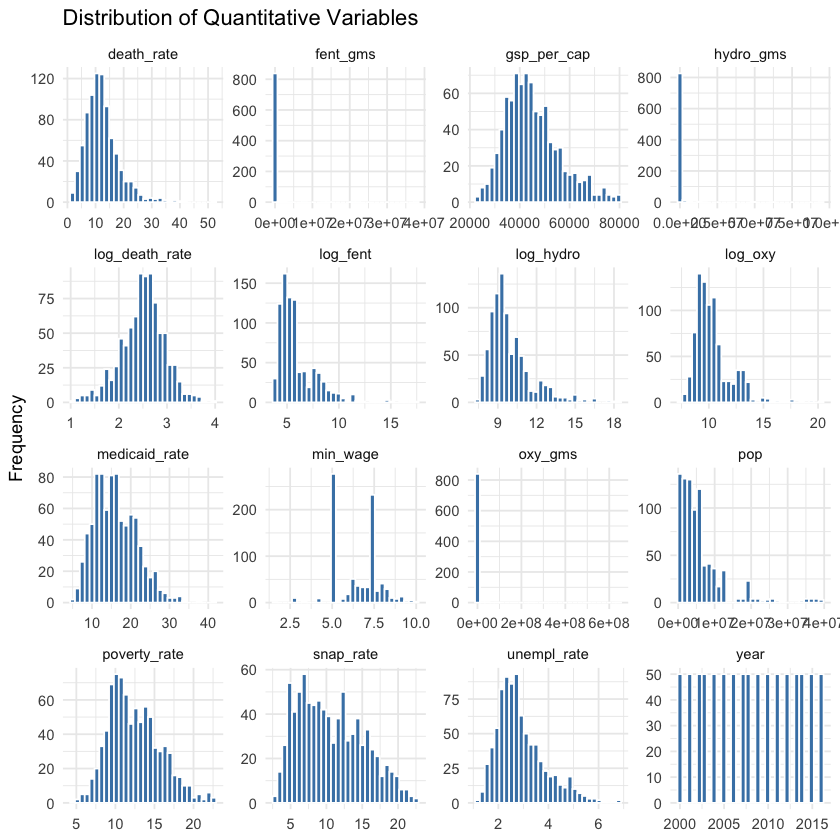

In [38]:
# Histograms for Numeric Variables
df |>
  select(where(is.numeric)) |>
  pivot_longer(cols = everything(),
               names_to = "variable",
               values_to = "value") |>
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  facet_wrap(~variable, scales = "free") +
  theme_minimal() +
  labs(title = "Distribution of Quantitative Variables",
       x = NULL,
       y = "Frequency")

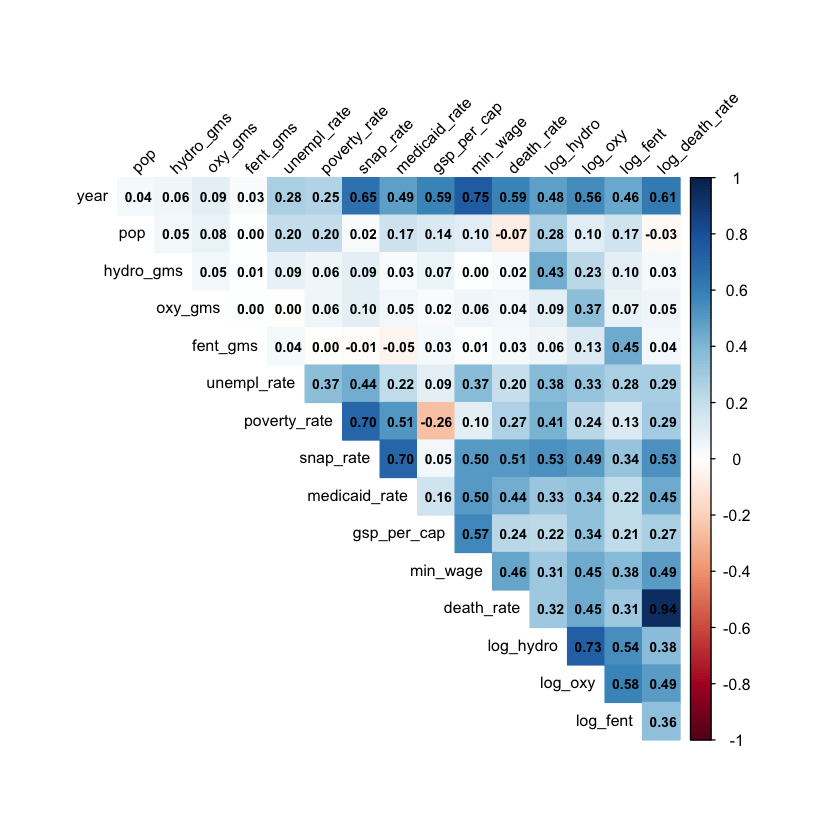

In [39]:
# Correlation Plot
cor_matrix <- df |>
  select(where(is.numeric)) |>
  cor(use = "complete.obs")

corrplot(cor_matrix,
         method = "color",
         type = "upper",
         addCoef.col = "black",
         number.cex = 0.7,
         tl.cex = 0.8,
         tl.col = "black",
         tl.srt = 45,
         diag = FALSE)

`geom_smooth()` using formula = 'y ~ x'


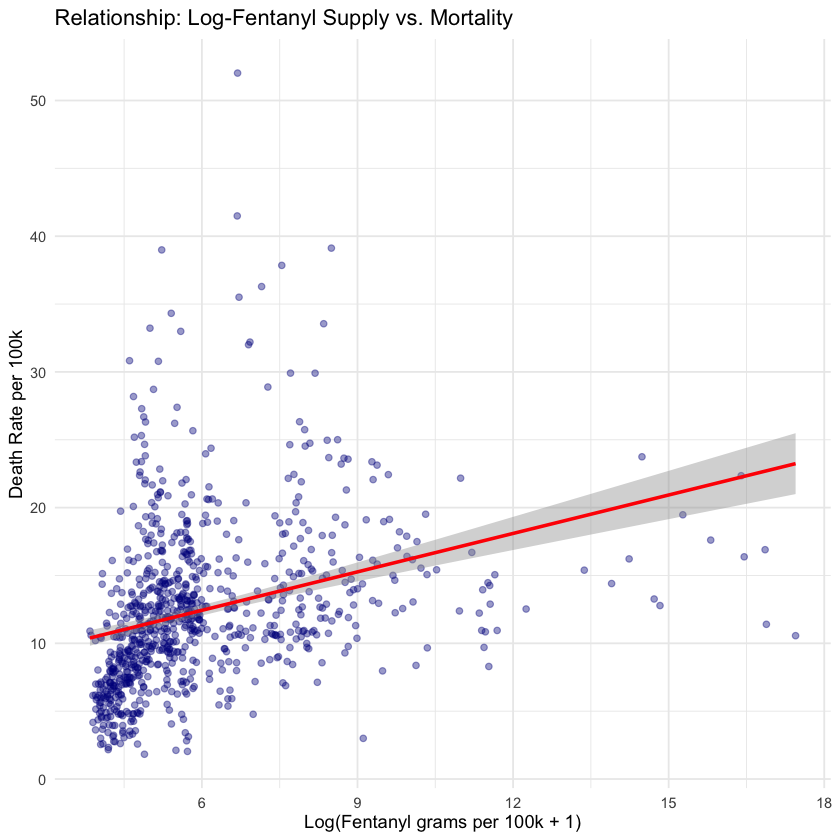

In [40]:
# Scatter plot of Log Fentanyl vs Death Rate
ggplot(df, aes(x = log_fent, y = death_rate)) +
  geom_point(alpha = 0.4, color = "darkblue") +
  geom_smooth(method = "lm", color = "red") + 
  labs(title = "Relationship: Log-Fentanyl Supply vs. Mortality",
       x = "Log(Fentanyl grams per 100k + 1)",
       y = "Death Rate per 100k") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


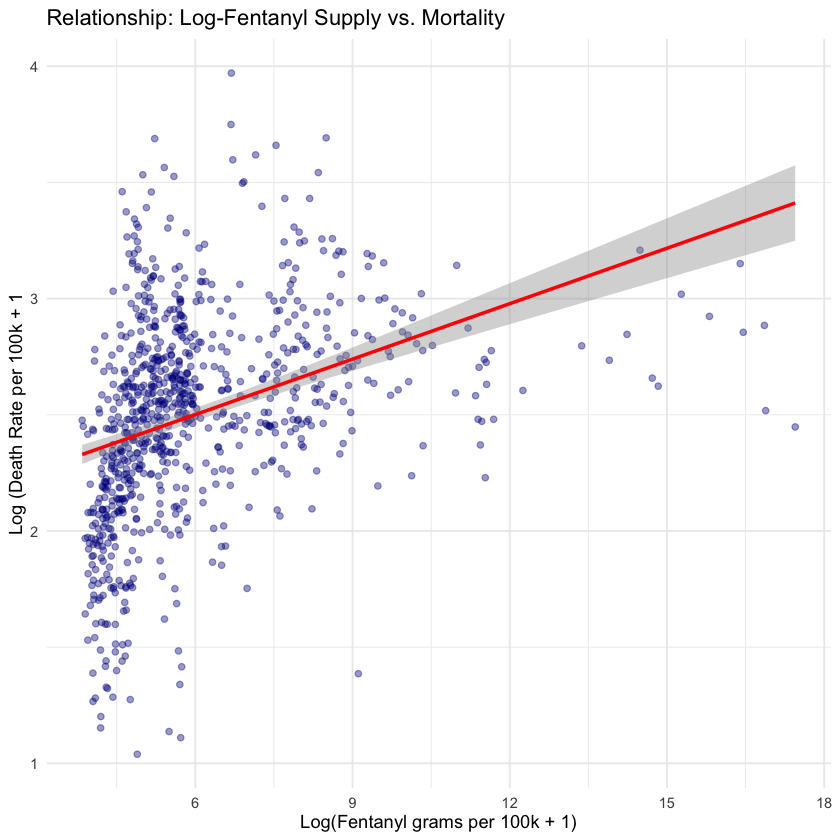

In [41]:
# Scatter plot of Log Fentanyl vs Death Rate
ggplot(df, aes(x = log_fent, y = log_death_rate)) +
  geom_point(alpha = 0.4, color = "darkblue") +
  geom_smooth(method = "lm", color = "red") + 
  labs(title = "Relationship: Log-Fentanyl Supply vs. Mortality",
       x = "Log(Fentanyl grams per 100k + 1)",
       y = "Log (Death Rate per 100k + 1") +
  theme_minimal()